In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.report import PerformanceReport

report = PerformanceReport()

print("PerformanceReport loaded successfully.")
print(
    "Research report generator:",
    hasattr(report, "generate_research_report")
)

PerformanceReport loaded successfully.
Research report generator: True


In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from src.strategies.momentum import MomentumStrategy
from src.strategies.mean_reversion import MeanReversionStrategy

from src.multi_strategy import MultiStrategyEngine
from src.portfolio_risk import PortfolioRiskManager
from src.report import PerformanceReport

In [4]:
prices = pd.read_csv(
    "../data/raw/daily_prices.csv",
    index_col=0,
    parse_dates=True
)

print("=" * 60)
print("QUANTLAB DATASET")
print("=" * 60)

print(f"Observations : {len(prices)}")
print(f"Assets       : {prices.shape[1]}")
print(f"Start Date   : {prices.index.min().date()}")
print(f"End Date     : {prices.index.max().date()}")

prices.head()

QUANTLAB DATASET
Observations : 6573
Assets       : 10
Start Date   : 2000-01-03
End Date     : 2026-02-20


,AAPL,AMZN,GOOGL,JNJ,JPM,KO,MSFT,NVDA,TSLA,XOM
Date,,,,,,,,,,
2000-01-03,0.84,4.47,NaN,23.41,22.91,13.61,35.60,0.09,NaN,17.14
2000-01-04,0.77,4.10,NaN,22.55,22.41,13.63,34.40,0.09,NaN,16.81
2000-01-05,0.78,3.49,NaN,22.79,22.27,13.75,34.76,0.08,NaN,17.73
2000-01-06,0.71,3.28,NaN,23.50,22.59,13.77,33.60,0.08,NaN,18.65
2000-01-07,0.75,3.48,NaN,24.50,23.00,14.67,34.04,0.08,NaN,18.59


In [5]:
strategies = {

    "Momentum": MomentumStrategy(
        lookback=13,
        top_n=3,
        bottom_n=3
    ),

    "Mean Reversion": MeanReversionStrategy(
        lookback=4,
        top_n=3,
        bottom_n=3
    )
}

print("=" * 60)
print("STRATEGY CONFIGURATION")
print("=" * 60)

print("Momentum")
print("  Lookback : 13 weeks")
print("  Longs    : 3")
print("  Shorts   : 3")

print("\nMean Reversion")
print("  Lookback : 4 weeks")
print("  Longs    : 3")
print("  Shorts   : 3")

STRATEGY CONFIGURATION
Momentum
  Lookback : 13 weeks
  Longs    : 3
  Shorts   : 3

Mean Reversion
  Lookback : 4 weeks
  Longs    : 3
  Shorts   : 3


In [6]:
engine = MultiStrategyEngine(
    strategies=strategies
)

results = engine.run_strategies(
    prices
)

strategy_returns = engine.strategy_returns(
    results
)

strategy_returns.head()

,Momentum,Mean Reversion
Date,,
2000-01-07,0.0,0.0
2000-01-14,0.0,0.0
2000-01-21,0.0,0.0
2000-01-28,0.0,0.0
2000-02-04,0.0,0.0


In [7]:
risk_manager = PortfolioRiskManager()

inverse_vol_weights = (
    risk_manager.inverse_volatility_weights(
        strategy_returns
    )
)

inverse_vol_weights

Momentum          0.509808
Mean Reversion    0.490192
Name: Inverse Volatility Weight, dtype: float64

In [8]:
risk_managed_returns = (
    risk_manager.portfolio_returns(
        strategy_returns,
        inverse_vol_weights
    )
)

risk_managed_returns.name = (
    "Risk Managed Portfolio"
)

In [9]:
master_returns = (
    strategy_returns.copy()
)

master_returns[
    "Risk Managed Portfolio"
] = risk_managed_returns

master_returns.head()

,Momentum,Mean Reversion,Risk Managed Portfolio
Date,,,
2000-01-07,0.0,0.0,0.0
2000-01-14,0.0,0.0,0.0
2000-01-21,0.0,0.0,0.0
2000-01-28,0.0,0.0,0.0
2000-02-04,0.0,0.0,0.0


In [10]:
report = PerformanceReport()

report_output = (
    report.generate_research_report(
        returns=master_returns,
        output_dir="../results",
        report_name="quantlab_final"
    )
)

print(
    "QuantLab research report generated successfully."
)

QuantLab research report generated successfully.


In [11]:
performance_table = (
    report_output["performance"]
)

performance_table

,CAGR,Annual Return,Annual Volatility,Sharpe Ratio,Sortino Ratio,Calmar Ratio,Maximum Drawdown,Win Rate,Best Week,Worst Week,Skewness,Kurtosis
Strategy,,,,,,,,,,,,
Momentum,0.051761,0.051761,0.306424,0.168920,0.251793,0.095583,-0.541531,0.518328,0.200475,-0.174256,0.162352,2.343342
Mean Reversion,-0.112107,-0.112107,0.318687,-0.351779,-0.481734,-0.115583,-0.969927,0.479472,0.188380,-0.365933,-0.455331,5.126295
Risk Managed Portfolio,0.003545,0.003545,0.162182,0.021855,0.027629,0.007934,-0.446724,0.502933,0.093393,-0.179378,-0.688464,7.730949


In [12]:
diagnostics = (
    report_output["diagnostics"]
)

diagnostics

,Observations,Valid Observations,Missing Observations,Zero Return Periods,Positive Periods,Negative Periods,Start Date,End Date
Strategy,,,,,,,,
Momentum,1364,1364,0,14,707,643,2000-01-07,2026-02-20
Mean Reversion,1364,1364,0,5,654,705,2000-01-07,2026-02-20
Risk Managed Portfolio,1364,1364,0,5,686,673,2000-01-07,2026-02-20


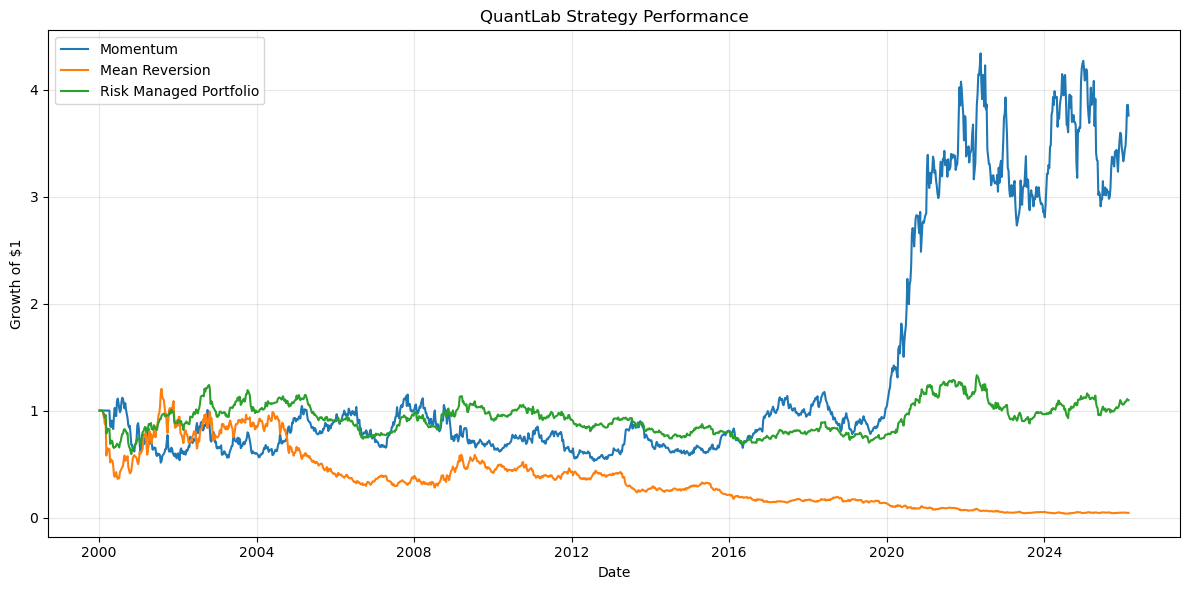

In [13]:
cumulative = (
    report_output["cumulative"]
)

plt.figure(
    figsize=(12, 6)
)

for column in cumulative.columns:

    plt.plot(
        cumulative.index,
        cumulative[column],
        label=column
    )

plt.title(
    "QuantLab Strategy Performance"
)

plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

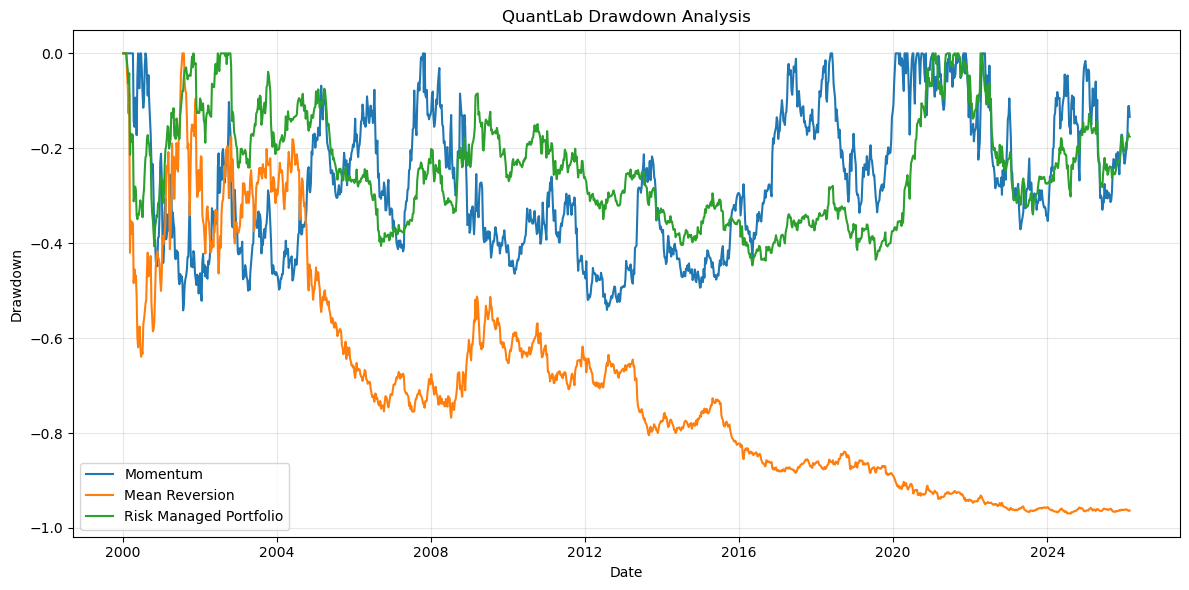

In [14]:
drawdown = (
    report_output["drawdown"]
)

plt.figure(
    figsize=(12, 6)
)

for column in drawdown.columns:

    plt.plot(
        drawdown.index,
        drawdown[column],
        label=column
    )

plt.title(
    "QuantLab Drawdown Analysis"
)

plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [15]:
correlation = (
    strategy_returns.corr()
)

correlation

,Momentum,Mean Reversion
Momentum,1.000000,-0.461093
Mean Reversion,-0.461093,1.000000


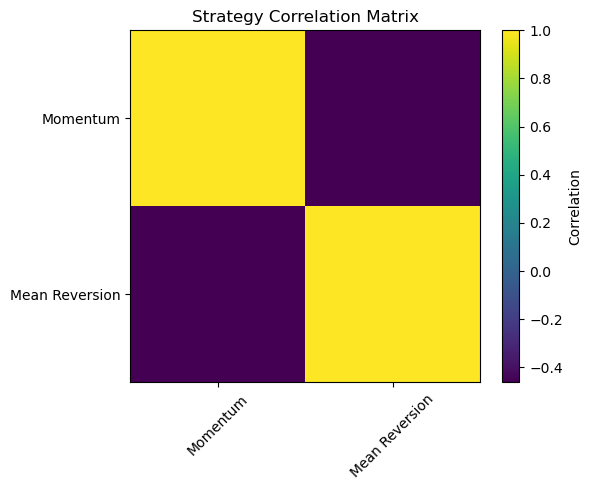

In [16]:
plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    correlation,
    aspect="auto"
)

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.index)),
    correlation.index
)

plt.colorbar(
    label="Correlation"
)

plt.title(
    "Strategy Correlation Matrix"
)

plt.tight_layout()
plt.show()

In [17]:
allocation_table = (
    inverse_vol_weights
    .to_frame(
        name="Portfolio Weight"
    )
)

allocation_table

,Portfolio Weight
Momentum,0.509808
Mean Reversion,0.490192


In [18]:
risk_contribution = (
    risk_manager.percentage_risk_contribution(
        strategy_returns,
        inverse_vol_weights
    )
)

risk_contribution = (
    risk_contribution
    .to_frame(
        name="Risk Contribution"
    )
)

risk_contribution

,Risk Contribution
Momentum,0.5
Mean Reversion,0.5


In [19]:
walk_forward_returns = pd.read_csv(
    "../results/walk_forward_oos_returns.csv",
    index_col=0,
    parse_dates=True
)

walk_forward_returns.head()

,Strategy Return
Date,
2005-01-07,0.002436
2005-01-14,-0.001825
2005-01-21,-0.023203
2005-01-28,0.030944
2005-02-04,0.088502


In [20]:
walk_forward_returns = (
    walk_forward_returns.iloc[:, 0]
)

walk_forward_returns.name = (
    "Walk-Forward OOS"
)

In [21]:
walk_forward_summary = (
    report.summary(
        walk_forward_returns
    )
)

walk_forward_summary

CAGR                -0.010398
Annual Return       -0.010398
Annual Volatility    0.271915
Sharpe Ratio        -0.038240
Sortino Ratio       -0.056197
Calmar Ratio        -0.016125
Maximum Drawdown    -0.644828
Win Rate             0.507260
Best Week            0.148848
Worst Week          -0.172778
Skewness            -0.083319
Kurtosis             1.686536
dtype: float64

In [22]:
factor_summary = pd.read_csv(
    "../results/factor_summary.csv",
    index_col=0
)

factor_summary

,0
Alpha,0.127720
Beta,-0.135252
Correlation,-0.095925
R Squared,0.009202
Tracking Error,0.392447
Information Ratio,-0.323592


In [23]:
print("=" * 70)
print("QUANTLAB — FINAL RESEARCH SUMMARY")
print("=" * 70)

print("\n1. STRATEGY ARCHITECTURE")
print(
    "Cross-sectional momentum and mean-reversion "
    "strategies implemented through a common research pipeline."
)

print("\n2. DIVERSIFICATION")
print(
    f"Momentum / Mean-Reversion Correlation: "
    f"{correlation.iloc[0, 1]:.3f}"
)

print("\n3. PORTFOLIO CONSTRUCTION")
print(
    "Inverse-volatility allocation used to balance "
    "strategy-level risk."
)

print("\n4. RISK ALLOCATION")

for strategy, value in (
    risk_contribution[
        "Risk Contribution"
    ].items()
):

    print(
        f"{strategy}: {value:.2%}"
    )

print("\n5. ROBUSTNESS")

print(
    f"Walk-Forward Sharpe: "
    f"{report.sharpe_ratio(walk_forward_returns):.3f}"
)

print(
    f"Walk-Forward Maximum Drawdown: "
    f"{report.max_drawdown(walk_forward_returns):.2%}"
)

print("\n6. RESEARCH CONCLUSION")

print(
    "Full-sample strategy results show diversification "
    "benefits across momentum and mean-reversion signals. "
    "However, walk-forward testing demonstrates substantial "
    "out-of-sample performance degradation, highlighting "
    "parameter instability and overfitting risk."
)

QUANTLAB — FINAL RESEARCH SUMMARY

1. STRATEGY ARCHITECTURE
Cross-sectional momentum and mean-reversion strategies implemented through a common research pipeline.

2. DIVERSIFICATION
Momentum / Mean-Reversion Correlation: -0.461

3. PORTFOLIO CONSTRUCTION
Inverse-volatility allocation used to balance strategy-level risk.

4. RISK ALLOCATION
Momentum: 50.00%
Mean Reversion: 50.00%

5. ROBUSTNESS
Walk-Forward Sharpe: -0.038
Walk-Forward Maximum Drawdown: -64.48%

6. RESEARCH CONCLUSION
Full-sample strategy results show diversification benefits across momentum and mean-reversion signals. However, walk-forward testing demonstrates substantial out-of-sample performance degradation, highlighting parameter instability and overfitting risk.


In [24]:
results_dir = Path(
    "../results"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

allocation_table.to_csv(
    results_dir /
    "final_portfolio_allocation.csv"
)

risk_contribution.to_csv(
    results_dir /
    "final_risk_contribution.csv"
)

walk_forward_summary.to_csv(
    results_dir /
    "final_walk_forward_summary.csv"
)

correlation.to_csv(
    results_dir /
    "final_strategy_correlation.csv"
)

print("=" * 60)
print("QUANTLAB REPORT COMPLETE")
print("=" * 60)

print(
    "Final research outputs saved to ../results/"
)

QUANTLAB REPORT COMPLETE
Final research outputs saved to ../results/
